In [27]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, RNN
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Some functions to help out with
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real IBM Stock Price')
    plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

In [3]:
# First, we get the data
dataset = pd.read_csv('./IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [4]:
dataset.shape

(3020, 6)

In [5]:
3020-60

2960

In [6]:
# Checking for missing values
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

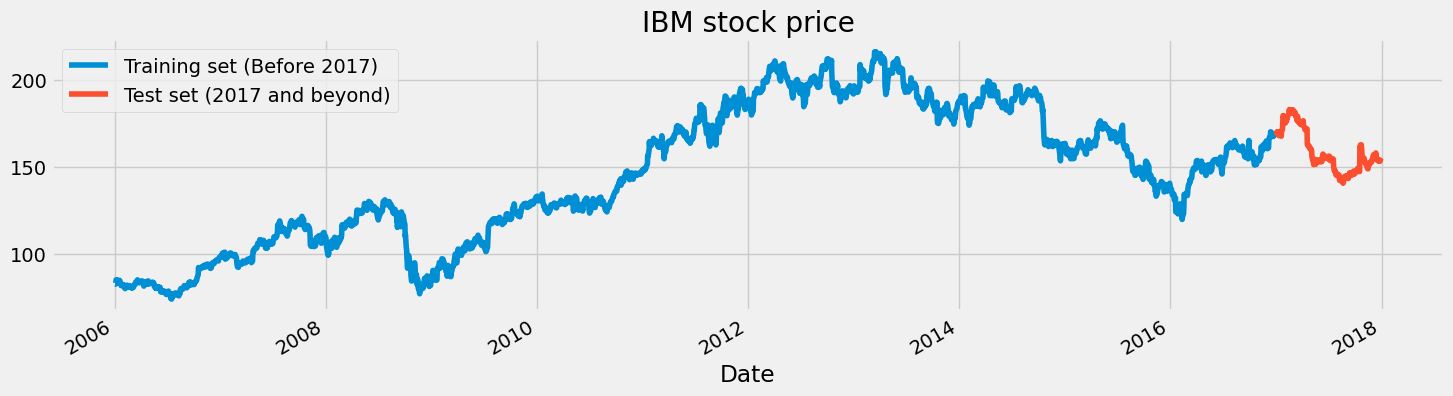

In [7]:
# We have chosen 'High' attribute for prices. Let's see what it looks like
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [8]:
training_set.shape

(2769, 1)

In [9]:
test_set.shape

(251, 1)

In [10]:
251+60

311

In [11]:
# Scaling the training set
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [16]:
# Since LSTMs store long term memory state, we create a data structure with 60 timesteps and 1 output
# So for each element of training set, we have 60 previous training set elements 
X_train = []
y_train = []
for i in range(60,2769):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [13]:
test=pd.DataFrame(X_train)

In [14]:
test.head()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,0.060651,0.060299,0.063116,0.078121,0.072626,0.071710,0.076571,0.070583,0.066991,0.064948,...,0.068893,0.066709,0.069104,0.077839,0.075655,0.072767,0.068893,0.065652,0.066568,0.067695
1,0.060299,0.063116,0.078121,0.072626,0.071710,0.076571,0.070583,0.066991,0.064948,0.075796,...,0.066709,0.069104,0.077839,0.075655,0.072767,0.068893,0.065652,0.066568,0.067695,0.068752
2,0.063116,0.078121,0.072626,0.071710,0.076571,0.070583,0.066991,0.064948,0.075796,0.073612,...,0.069104,0.077839,0.075655,0.072767,0.068893,0.065652,0.066568,0.067695,0.068752,0.068047
3,0.078121,0.072626,0.071710,0.076571,0.070583,0.066991,0.064948,0.075796,0.073612,0.064173,...,0.077839,0.075655,0.072767,0.068893,0.065652,0.066568,0.067695,0.068752,0.068047,0.067977
4,0.072626,0.071710,0.076571,0.070583,0.066991,0.064948,0.075796,0.073612,0.064173,0.056213,...,0.075655,0.072767,0.068893,0.065652,0.066568,0.067695,0.068752,0.068047,0.067977,0.069315


In [17]:
# Reshaping X_train for efficient modelling
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

In [28]:
# The LSTM architecture
regressor = Sequential()
# First LSTM layer with Dropout regularisation
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2))
# Second LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Third LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Fourth LSTM layer
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
# The output layer
regressor.add(Dense(units=1))

# Compiling the LSTM
regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
# Fitting to the training set
regressor.fit(X_train,y_train,epochs=10,batch_size=32)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0206
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0097
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0084
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0071
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0060
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0058
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0053
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - loss: 0.0047
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0043
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0041


In [19]:
# Now to get the test set ready in a similar way as the training set.
# The following has been done so forst 60 entires of test set have 60 previous values which is impossible to get unless we take the whole 
# 'High' attribute data for processing
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

In [20]:
# Preparing X_test and predicting the prices
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step


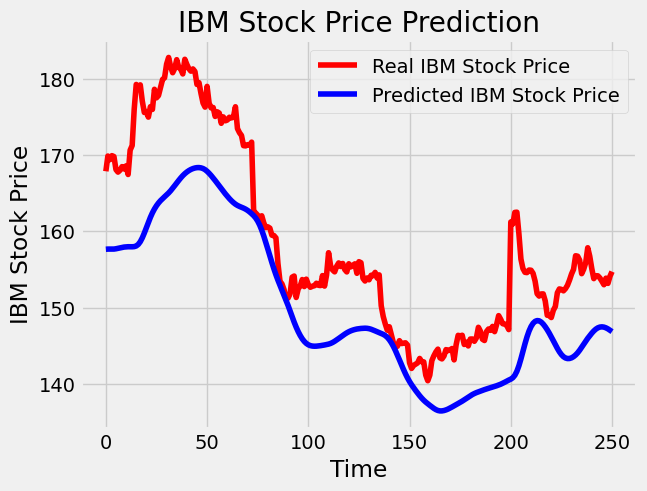

In [21]:
# Visualizing the results for LSTM
plot_predictions(test_set,predicted_stock_price)

In [22]:
# Evaluating our model
return_rmse(test_set,predicted_stock_price)

The root mean squared error is 9.483671188983283.


In [23]:
# The GRU architecture
regressorGRU = Sequential()
# First GRU layer with Dropout regularisation
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Second GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Third GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Fourth GRU layer
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# The output layer
regressorGRU.add(Dense(units=1))
# Compiling the RNN
regressorGRU.compile(optimizer=SGD( momentum=0.9, nesterov=False),loss='mean_squared_error')
# Fitting to the training set
regressorGRU.fit(X_train,y_train,epochs=50,batch_size=150)

C:\Users\tanya\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step - loss: 0.1218
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - loss: 0.0460
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - loss: 0.0157
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - loss: 0.0052
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 216ms/step - loss: 0.0044
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - loss: 0.0042
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - loss: 0.0041
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - loss: 0.0039
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - loss: 0.0036
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - loss: 0.0035
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step - loss: 0.0034
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - loss: 0.0033
Epoch 13/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - loss: 0.0030
Epoch 14/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - loss: 0.0033
Epoch 15/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - l

In [24]:
# Preparing X_test and predicting the prices
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step


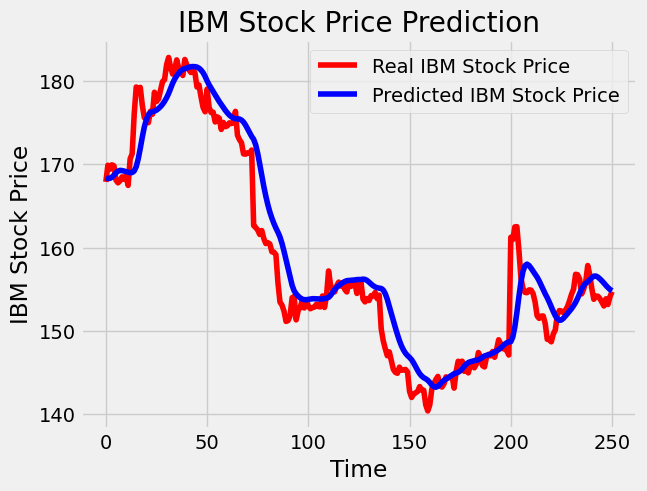

In [25]:
# Visualizing the results for GRU
plot_predictions(test_set,GRU_predicted_stock_price)

In [26]:
# Evaluating GRU
return_rmse(test_set,GRU_predicted_stock_price)

The root mean squared error is 3.354065512269124.
